In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import os

# Prevent OpenMP / temporary directory issues that can crash the notebook kernel
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["TMPDIR"] = "/tmp"

print("Environment configured: OMP_NUM_THREADS=1, TMPDIR=/tmp")

Environment configured: OMP_NUM_THREADS=1, TMPDIR=/tmp


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

RESULTS = Path("../outputs/results")

community_features = pd.read_csv(
    RESULTS / "community_features.csv"
)

timeline = pd.read_csv(
    RESULTS / "community_timelines.csv"
)

ranking = pd.read_csv(
    RESULTS / "afei_ranking.csv"
)

tracking = pd.read_csv(
    RESULTS / "community_tracking.csv"
)

summary = pd.read_csv(
    RESULTS / "timeline_summary.csv"
)

In [4]:
print("Communities:", community_features["pcid"].nunique())
print("Snapshots:", community_features["timestep"].nunique())

print(summary.head())

Communities: 317
Snapshots: 4
   pcid  birth  death  lifetime  persistence  snapshots
0     0     20     20         1            1          1
1     1     20     20         1            1          1
2     2     20     20         1            1          1
3     3     20     20         1            1          1
4     4     20     20         1            1          1


In [5]:
best = ranking.iloc[0]["pcid"]

In [6]:
case = community_features[
    community_features["pcid"] == best
].sort_values("timestep")

In [8]:
print(community_features.columns.tolist())
print(ranking.columns.tolist())

['pcid', 'timestep', 'community', 'growth_rate', 'density_change', 'degree_change', 'fraud_growth', 'clustering_change', 'feature_drift', 'variance_drift', 'lifetime', 'persistence', 'average_match_score', 'node_churn', 'structural_stability', 'is_fraud_community']
['pcid', 'timestep', 'community', 'growth_rate', 'density_change', 'degree_change', 'fraud_growth', 'clustering_change', 'feature_drift', 'variance_drift', 'lifetime', 'persistence', 'average_match_score', 'node_churn', 'structural_stability', 'is_fraud_community', 'afei', 'feature_contributions']


In [9]:
community_features.head()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community
0,6,21,11,-0.151515,0.178571,-0.043478,1.357143,0.0,4.610801,0.295710,2,0.4,0.859100,1.848485,0.931084,1
1,11,21,18,0.666667,-0.169231,0.530612,-1.000000,0.0,4.278830,0.730030,2,0.4,0.903350,2.666667,0.810845,0
2,15,21,9,0.000000,0.000000,0.000000,0.000000,0.0,9.080104,0.000000,3,0.6,0.915467,2.000000,1.000000,0
3,15,22,457,0.000000,0.000000,0.000000,0.000000,0.0,4.331653,0.000000,3,0.6,0.915467,2.000000,1.000000,0
4,18,21,87,-0.391304,0.642857,0.008117,0.000000,0.0,3.258021,0.064171,4,0.8,0.793975,1.608696,0.821699,1


In [10]:
analysis_df = community_features.merge(
    ranking[
        [
            "pcid",
            "timestep",
            "community",
            "afei",
            "feature_contributions",
        ]
    ],
    on=["pcid", "timestep", "community"],
    how="left",
)

analysis_df.head()

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community,afei,feature_contributions
0,6,21,11,-0.151515,0.178571,-0.043478,1.357143,0.0,4.610801,0.295710,2,0.4,0.859100,1.848485,0.931084,1,0.388072,{'growth_rate': np.float64(0.02556065239551479...
1,11,21,18,0.666667,-0.169231,0.530612,-1.000000,0.0,4.278830,0.730030,2,0.4,0.903350,2.666667,0.810845,0,0.266113,{'growth_rate': np.float64(0.05101936799184507...
2,15,21,9,0.000000,0.000000,0.000000,0.000000,0.0,9.080104,0.000000,3,0.6,0.915467,2.000000,1.000000,0,0.283116,{'growth_rate': np.float64(0.03027522935779816...
3,15,22,457,0.000000,0.000000,0.000000,0.000000,0.0,4.331653,0.000000,3,0.6,0.915467,2.000000,1.000000,0,0.270529,{'growth_rate': np.float64(0.03027522935779816...
4,18,21,87,-0.391304,0.642857,0.008117,0.000000,0.0,3.258021,0.064171,4,0.8,0.793975,1.608696,0.821699,1,0.283500,{'growth_rate': np.float64(0.01809932189868369...


In [11]:
top10 = (
    analysis_df
    .sort_values("afei", ascending=False)
    .drop_duplicates("pcid")
    .head(10)
)

top10[
    [
        "pcid",
        "timestep",
        "afei",
        "fraud_growth",
        "growth_rate",
        "node_churn",
    ]
]

,pcid,timestep,afei,fraud_growth,growth_rate,node_churn
111,161,22,0.535940,0.000000,5.200000,7.200000
37,66,21,0.534805,0.000000,4.666667,6.666667
301,330,22,0.496548,0.000000,5.454545,7.454545
515,855,24,0.464409,0.000000,3.500000,5.500000
56,92,21,0.442697,0.000000,2.750000,4.750000
391,585,23,0.409458,0.000000,0.000000,2.000000
523,875,24,0.400302,0.000000,0.000000,2.000000
152,212,21,0.398229,0.000000,2.250000,4.250000
384,531,23,0.390048,0.000000,2.250000,4.250000
0,6,21,0.388072,1.357143,-0.151515,1.848485


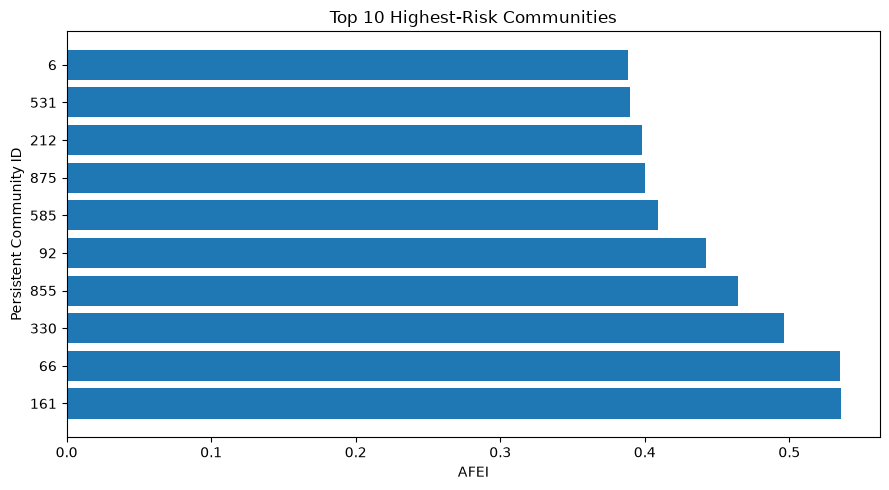

In [12]:
plt.figure(figsize=(9,5))

plt.barh(
    top10["pcid"].astype(str),
    top10["afei"]
)

plt.xlabel("AFEI")
plt.ylabel("Persistent Community ID")
plt.title("Top 10 Highest-Risk Communities")

plt.tight_layout()

In [14]:
best = top10.iloc[0]["pcid"]

case = (
    analysis_df[
        analysis_df["pcid"] == best
    ]
    .sort_values("timestep")
)

case

,pcid,timestep,community,growth_rate,density_change,degree_change,fraud_growth,clustering_change,feature_drift,variance_drift,lifetime,persistence,average_match_score,node_churn,structural_stability,is_fraud_community,afei,feature_contributions
110,161,21,56,0.000000,0.000000,0.000,0.000000,0.0,8.124070,27.738211,5,1.0,0.87366,2.000000,1.000000,0,0.313081,{'growth_rate': np.float64(0.03027522935779816...
111,161,22,18,5.200000,-0.838710,0.250,0.000000,0.0,4.761240,0.295149,5,1.0,0.87366,7.200000,0.733728,1,0.535940,{'growth_rate': np.float64(0.19207951070336393...
112,161,23,12,-0.032258,0.033333,0.000,0.033333,0.0,8.953781,0.371922,5,1.0,0.87366,1.967742,0.989011,1,0.286446,{'growth_rate': np.float64(0.02927148071421526...
113,161,24,17,0.333333,-0.250000,0.025,0.500000,0.0,7.666953,-0.488669,5,1.0,0.87366,2.333333,0.916031,1,0.340347,{'growth_rate': np.float64(0.04064729867482161...


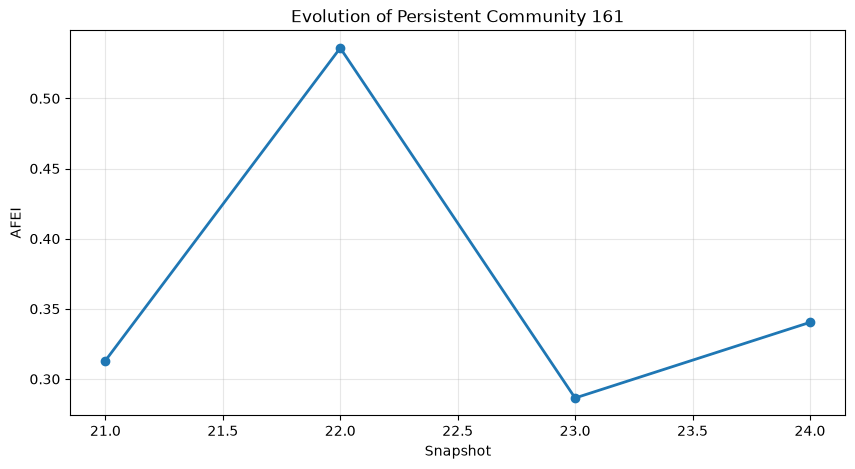

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    case["timestep"],
    case["afei"],
    marker="o",
    linewidth=2
)

plt.xlabel("Snapshot")
plt.ylabel("AFEI")

plt.title(
    f"Evolution of Persistent Community {best}"
)

plt.grid(alpha=0.3)

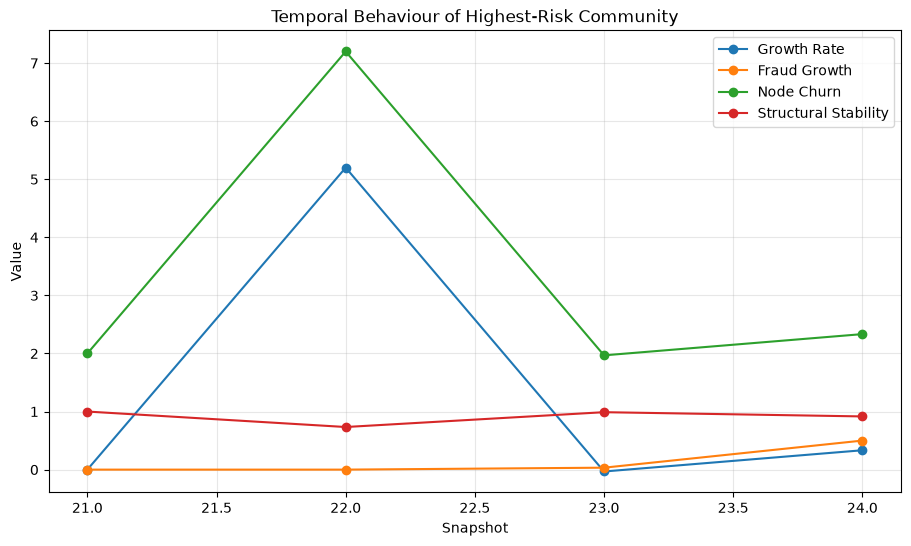

In [16]:
plt.figure(figsize=(11,6))

plt.plot(
    case["timestep"],
    case["growth_rate"],
    marker="o",
    label="Growth Rate"
)

plt.plot(
    case["timestep"],
    case["fraud_growth"],
    marker="o",
    label="Fraud Growth"
)

plt.plot(
    case["timestep"],
    case["node_churn"],
    marker="o",
    label="Node Churn"
)

plt.plot(
    case["timestep"],
    case["structural_stability"],
    marker="o",
    label="Structural Stability"
)

plt.legend()

plt.xlabel("Snapshot")
plt.ylabel("Value")

plt.title(
    "Temporal Behaviour of Highest-Risk Community"
)

plt.grid(alpha=0.3)

Text(0, 0.5, 'AFEI')

<Figure size 800x500 with 0 Axes>

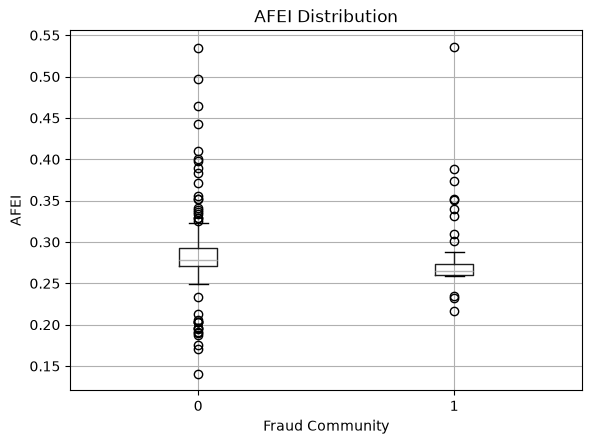

In [17]:
plt.figure(figsize=(8,5))

analysis_df.boxplot(
    column="afei",
    by="is_fraud_community"
)

plt.suptitle("")
plt.title("AFEI Distribution")

plt.xlabel("Fraud Community")
plt.ylabel("AFEI")

In [19]:
from pathlib import Path

RESULTS = Path("../outputs/results")
RESULTS.mkdir(parents=True, exist_ok=True)

In [20]:
features = [
    "growth_rate",
    "density_change",
    "degree_change",
    "fraud_growth",
    "clustering_change",
    "feature_drift",
    "variance_drift",
    "lifetime",
    "persistence",
    "average_match_score",
    "node_churn",
    "structural_stability",
    "afei",
]

corr = analysis_df[features].corr()

corr.to_csv(
    RESULTS / "feature_correlation_matrix.csv"
)

print("Saved feature_correlation_matrix.csv")

Saved feature_correlation_matrix.csv


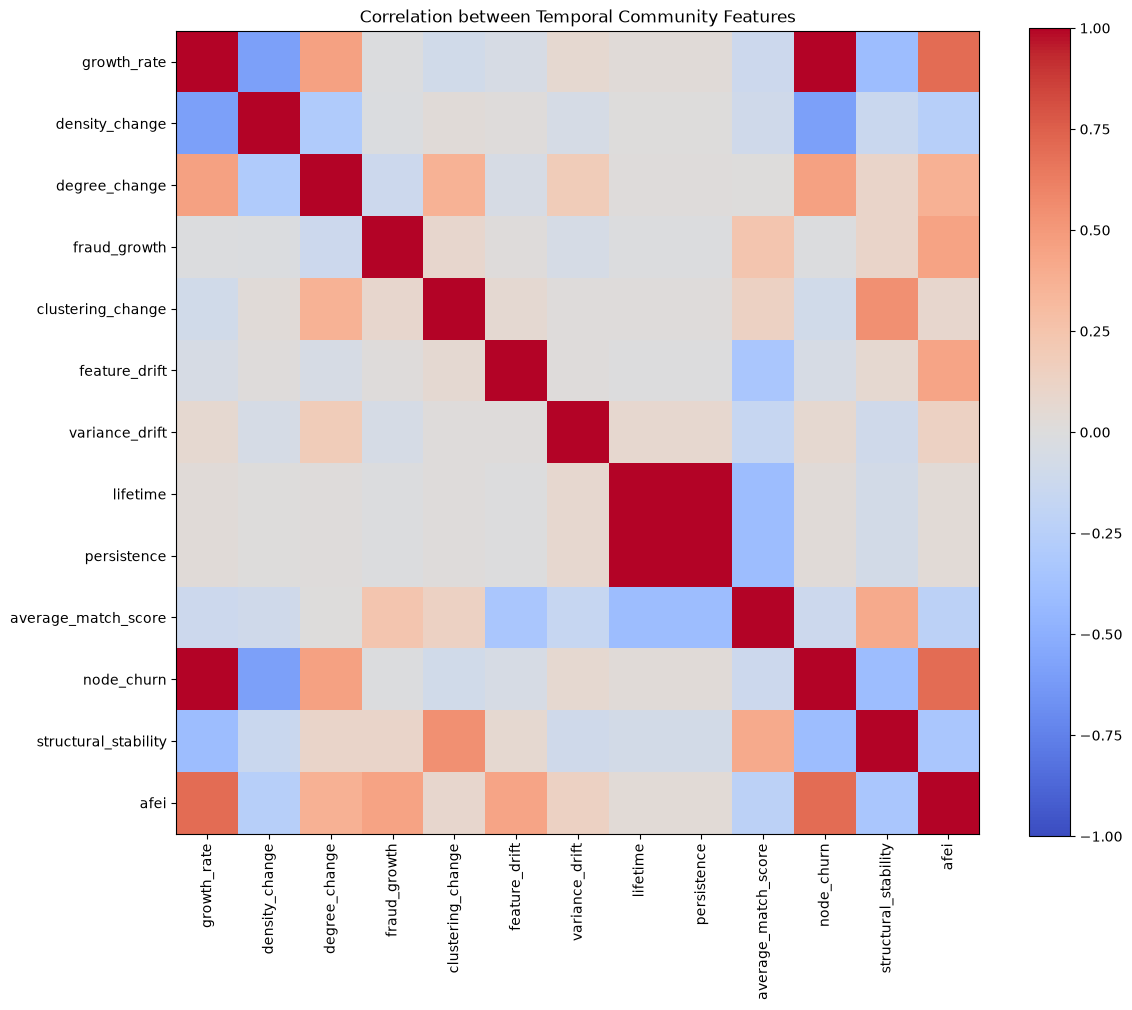

Saved feature_correlation_heatmap.png


In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,10))

im = plt.imshow(
    corr,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.xticks(
    range(len(features)),
    features,
    rotation=90
)

plt.yticks(
    range(len(features)),
    features
)

plt.colorbar(im)

plt.title("Correlation between Temporal Community Features")

plt.tight_layout()

plt.savefig(
    RESULTS / "feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved feature_correlation_heatmap.png")

In [23]:
top10.to_csv(
    RESULTS / "top10_risk_communities.csv",
    index=False,
)

In [24]:
case.to_csv(
    RESULTS / f"community_{int(best)}_timeline.csv",
    index=False,
)

In [25]:
analysis_df.to_csv(
    RESULTS / "analysis_dataset.csv",
    index=False,
)

In [35]:
analysis_df["feature_contributions"].iloc[0]

{'growth_rate': 0.02556065239551479,
 'density_change': 0.02946428571428571,
 'degree_change': 0.06194616977225673,
 'fraud_growth': 0.2,
 'clustering_change': 0.038262910798122066,
 'feature_drift': 0.011811373516494297,
 'variance_drift': 0.001518092208118625,
 'node_churn': 0.012780326197757392,
 'structural_stability': 0.006728590035818938}

In [36]:
print(type(analysis_df["feature_contributions"].iloc[0]))

<class 'dict'>


In [37]:
for i in range(5):
    print(f"\nRow {i}")
    print(type(analysis_df["feature_contributions"].iloc[i]))
    print(analysis_df["feature_contributions"].iloc[i])


Row 0
<class 'dict'>
{'growth_rate': 0.02556065239551479, 'density_change': 0.02946428571428571, 'degree_change': 0.06194616977225673, 'fraud_growth': 0.2, 'clustering_change': 0.038262910798122066, 'feature_drift': 0.011811373516494297, 'variance_drift': 0.001518092208118625, 'node_churn': 0.012780326197757392, 'structural_stability': 0.006728590035818938}

Row 1
<class 'dict'>
{'growth_rate': 0.05101936799184507, 'density_change': 0.020769230769230776, 'degree_change': 0.0991253644314869, 'fraud_growth': 0.0, 'clustering_change': 0.038262910798122066, 'feature_drift': 0.010931407399159212, 'variance_drift': 0.0020269555218477143, 'node_churn': 0.02550968399592253, 'structural_stability': 0.018468153107282437}

Row 2
<class 'dict'>
{'growth_rate': 0.030275229357798167, 'density_change': 0.025, 'degree_change': 0.06476190476190477, 'fraud_growth': 0.08484848484848487, 'clustering_change': 0.038262910798122066, 'feature_drift': 0.02365827264643409, 'variance_drift': 0.00117163001109945

In [41]:
import pandas as pd
import numpy as np

contributions = {}

for contrib_dict in analysis_df["feature_contributions"]:
    for feature, value in contrib_dict.items():
        contributions.setdefault(feature, []).append(value)

avg_contributions = (
    pd.Series(
        {feature: np.mean(values) for feature, values in contributions.items()}
    )
    .sort_values(ascending=False)
)

avg_contributions

fraud_growth            0.082498
degree_change           0.064695
clustering_change       0.037858
growth_rate             0.032078
density_change          0.025116
feature_drift           0.019612
node_churn              0.016039
structural_stability    0.002017
variance_drift          0.001491
dtype: float64

In [42]:
avg_contributions_df = avg_contributions.reset_index()
avg_contributions_df.columns = [
    "Feature",
    "Average Contribution"
]

avg_contributions_df.to_csv(
    RESULTS / "average_feature_contributions.csv",
    index=False
)

avg_contributions_df

,Feature,Average Contribution
0,fraud_growth,0.082498
1,degree_change,0.064695
2,clustering_change,0.037858
3,growth_rate,0.032078
4,density_change,0.025116
5,feature_drift,0.019612
6,node_churn,0.016039
7,structural_stability,0.002017
8,variance_drift,0.001491


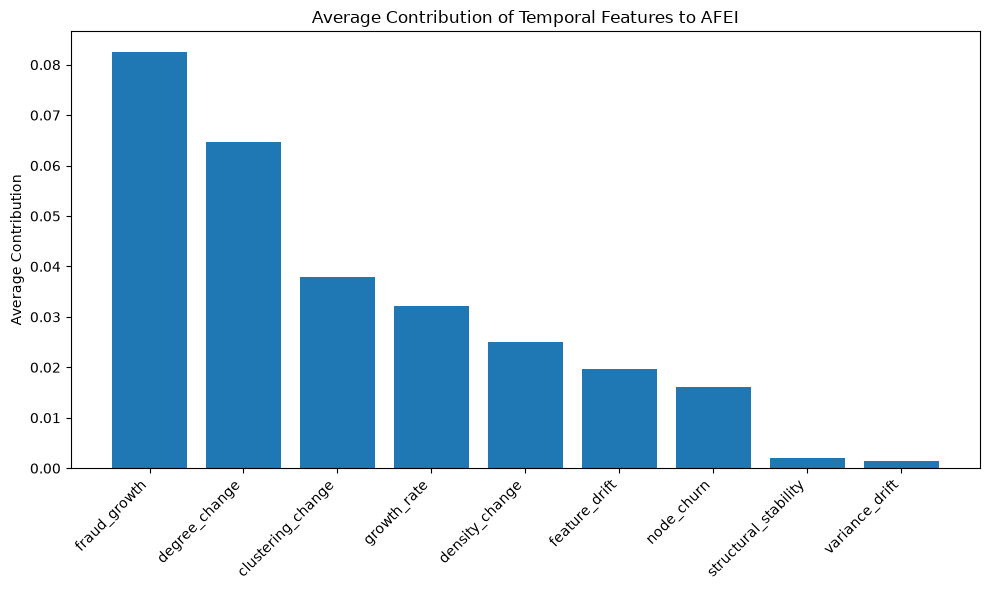

In [43]:
plt.figure(figsize=(10,6))

plt.bar(
    avg_contributions_df["Feature"],
    avg_contributions_df["Average Contribution"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Average Contribution")

plt.title("Average Contribution of Temporal Features to AFEI")

plt.tight_layout()

plt.savefig(
    RESULTS / "feature_contributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
best = top10.iloc[0]["pcid"]

case = (
    analysis_df[analysis_df["pcid"] == best]
    .sort_values("timestep")
)

latest = case.iloc[-1]

feature_scores = pd.Series(
    latest["feature_contributions"]
).sort_values(ascending=False)

feature_scores

fraud_growth            0.127273
degree_change           0.066381
growth_rate             0.040647
clustering_change       0.038263
node_churn              0.020324
feature_drift           0.019912
density_change          0.018750
structural_stability    0.008198
variance_drift          0.000599
dtype: float64

In [45]:
feature_scores.to_frame(
    name="Contribution"
).to_csv(
    RESULTS / f"community_{int(best)}_feature_contributions.csv"
)

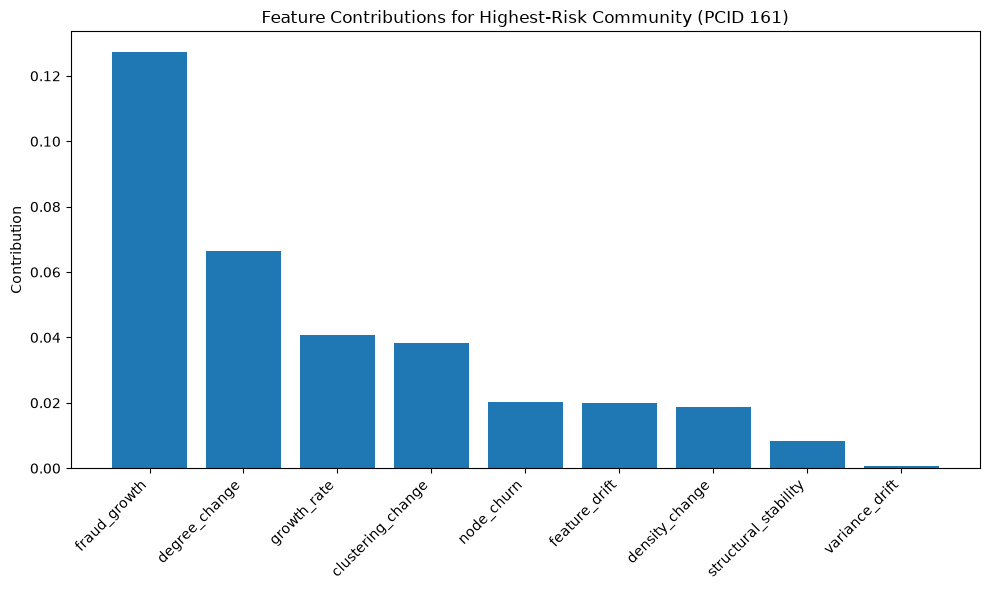

In [46]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_scores.index,
    feature_scores.values
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Contribution")

plt.title(
    f"Feature Contributions for Highest-Risk Community (PCID {int(best)})"
)

plt.tight_layout()

plt.savefig(
    RESULTS / f"community_{int(best)}_feature_contributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FINAL PHASE

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from pathlib import Path

In [49]:
from src.graph.builder import TemporalGraphBuilder
from src.graph.manager import TemporalGraphManager
from src.community.detector import CommunityDetector
from src.community.matcher import CommunityMatcher
from src.community.tracker import CommunityTracker

In [50]:
from src.config import (
    FEATURE_FILE,
    CLASS_FILE,
    EDGE_FILE,
    DEV_SNAPSHOTS,
)

In [52]:
from src.graph.manager import TemporalGraphManager
from src.config import ALL_SNAPSHOTS

manager = TemporalGraphManager()

manager.build_all(ALL_SNAPSHOTS)

2026-07-20 14:59:02,158 | INFO | Loading processed dataset...
2026-07-20 14:59:14,719 | INFO | Dataset loaded successfully.
2026-07-20 14:59:14,721 | INFO | Building temporal graphs...
2026-07-20 14:59:14,722 | INFO | Building graph for timestep 1
2026-07-20 14:59:15,157 | INFO | Graph built successfully | Nodes: 2147 | Edges: 1924
2026-07-20 14:59:15,159 | INFO | Snapshot 1 validated.
2026-07-20 14:59:15,284 | INFO | Detected 437 communities.
2026-07-20 14:59:15,288 | INFO | Building graph for timestep 2
2026-07-20 14:59:15,701 | INFO | Graph built successfully | Nodes: 1117 | Edges: 858
2026-07-20 14:59:15,702 | INFO | Snapshot 2 validated.
2026-07-20 14:59:15,760 | INFO | Detected 322 communities.
2026-07-20 14:59:15,762 | INFO | Building graph for timestep 3
2026-07-20 14:59:16,021 | INFO | Graph built successfully | Nodes: 1279 | Edges: 727
2026-07-20 14:59:16,023 | INFO | Snapshot 3 validated.
2026-07-20 14:59:16,086 | INFO | Detected 558 communities.
2026-07-20 14:59:16,089 | IN

In [53]:
from src.community.tracker import CommunityTracker

tracker = CommunityTracker()

tracker.track(manager.graphs)

In [54]:
from src.community.timeline import CommunityTimeline

timeline = CommunityTimeline()

timeline.build(
    tracker,
    manager.graphs,
)

2026-07-20 15:04:40,981 | INFO | Built 9328 community timelines.


In [55]:
print(type(manager.get_snapshot(20)))
print(type(manager.graphs))
print(len(manager.graphs))

<class 'networkx.classes.digraph.DiGraph'>
<class 'dict'>
49


In [56]:
top_pcid = (
    analysis_df.sort_values("afei", ascending=False)
    .iloc[0]["pcid"]
)

print("Highest Risk PCID:", top_pcid)

Highest Risk PCID: 161


In [57]:
case = (
    analysis_df[analysis_df["pcid"] == top_pcid]
    .sort_values("timestep")
)

case[["timestep", "community", "afei"]]

,timestep,community,afei
110,21,56,0.313081
111,22,18,0.535940
112,23,12,0.286446
113,24,17,0.340347


In [60]:
dir(tracker)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'community_map',
 'get_metadata',
 'get_pcid',
 'get_score',
 'initialize',
 'next_pcid',
 'track',
 'update']

In [61]:
tracker.__dict__

{'next_pcid': 9328,
 'community_map': {(1, 0): {'pcid': 0,
   'previous_community': None,
   'current_community': 0,
   'score': 1.0},
  (1, 1): {'pcid': 1,
   'previous_community': None,
   'current_community': 1,
   'score': 1.0},
  (1, 2): {'pcid': 2,
   'previous_community': None,
   'current_community': 2,
   'score': 1.0},
  (1, 3): {'pcid': 3,
   'previous_community': None,
   'current_community': 3,
   'score': 1.0},
  (1, 4): {'pcid': 4,
   'previous_community': None,
   'current_community': 4,
   'score': 1.0},
  (1, 5): {'pcid': 5,
   'previous_community': None,
   'current_community': 5,
   'score': 1.0},
  (1, 6): {'pcid': 6,
   'previous_community': None,
   'current_community': 6,
   'score': 1.0},
  (1, 7): {'pcid': 7,
   'previous_community': None,
   'current_community': 7,
   'score': 1.0},
  (1, 8): {'pcid': 8,
   'previous_community': None,
   'current_community': 8,
   'score': 1.0},
  (1, 9): {'pcid': 9,
   'previous_community': None,
   'current_community': 9,
 

In [62]:

timeline.__dict__

{'timelines': {0: [{'timestep': 1,
    'graph': <networkx.classes.digraph.DiGraph at 0x1184634d0>,
    'community': 0,
    'previous_community': None,
    'score': 1.0}],
  1: [{'timestep': 1,
    'graph': <networkx.classes.digraph.DiGraph at 0x1184634d0>,
    'community': 1,
    'previous_community': None,
    'score': 1.0}],
  2: [{'timestep': 1,
    'graph': <networkx.classes.digraph.DiGraph at 0x1184634d0>,
    'community': 2,
    'previous_community': None,
    'score': 1.0}],
  3: [{'timestep': 1,
    'graph': <networkx.classes.digraph.DiGraph at 0x1184634d0>,
    'community': 3,
    'previous_community': None,
    'score': 1.0},
   {'timestep': 2,
    'graph': <networkx.classes.digraph.DiGraph at 0x11895b9d0>,
    'community': 34,
    'previous_community': 3,
    'score': np.float64(0.5945)}],
  4: [{'timestep': 1,
    'graph': <networkx.classes.digraph.DiGraph at 0x1184634d0>,
    'community': 4,
    'previous_community': None,
    'score': 1.0}],
  5: [{'timestep': 1,
    'gra

In [63]:
entry = timeline.timelines[top_pcid][0]

G = entry["graph"]

print(type(G))
print(G.number_of_nodes())
print(G.number_of_edges())

<class 'networkx.classes.digraph.DiGraph'>
2147
1924


In [64]:
node = list(G.nodes())[0]

print(node)
print(G.nodes[node])

232438397.0
{'label': 0, 'timestep': 1, 'features': array([ 0.16305412,  1.96378976, -0.64637613, 12.4092943 , -0.06372457,
        9.78274214, 12.41455757, -0.16364521, -0.11583146,  0.04359831,
       -0.16390494,  1.05999328,  2.39745727, -0.06319995, -0.01328161,
        4.80023988,  0.17432904, -0.17290814,  0.61939932, -0.24329965,
       -0.24345165, -0.13973183, -0.14689536, -0.07966741, -0.15555351,
        0.77384681,  0.37851566, -0.13973363, -0.14689052, -0.07966688,
       -0.15555347,  0.77393165,  0.37859288, -0.02466883, -0.03127064,
       -0.02304392, -0.02621463,  0.10100803,  0.02631532, -0.22721545,
       -0.15677165,  0.08930672, -0.21219499, -2.77201477, -2.37196859,
       -0.22720332, -0.22115122, -0.06685777, -0.23201068, -2.16553357,
       -2.17585502, -0.41400813,  4.18119239,  4.34663973,  1.77796307,
       -1.45154458, -1.53025021,  4.6286834 ,  0.51380446, -0.16312599,
        1.20821954, -0.19643465, -0.19618884,  4.62965017,  0.51386947,
       -0.16

In [65]:
list(G.nodes(data=True))[:5]

[(np.float64(232438397.0),
  {'label': 0,
   'timestep': 1,
   'features': array([ 0.16305412,  1.96378976, -0.64637613, 12.4092943 , -0.06372457,
           9.78274214, 12.41455757, -0.16364521, -0.11583146,  0.04359831,
          -0.16390494,  1.05999328,  2.39745727, -0.06319995, -0.01328161,
           4.80023988,  0.17432904, -0.17290814,  0.61939932, -0.24329965,
          -0.24345165, -0.13973183, -0.14689536, -0.07966741, -0.15555351,
           0.77384681,  0.37851566, -0.13973363, -0.14689052, -0.07966688,
          -0.15555347,  0.77393165,  0.37859288, -0.02466883, -0.03127064,
          -0.02304392, -0.02621463,  0.10100803,  0.02631532, -0.22721545,
          -0.15677165,  0.08930672, -0.21219499, -2.77201477, -2.37196859,
          -0.22720332, -0.22115122, -0.06685777, -0.23201068, -2.16553357,
          -2.17585502, -0.41400813,  4.18119239,  4.34663973,  1.77796307,
          -1.45154458, -1.53025021,  4.6286834 ,  0.51380446, -0.16312599,
           1.20821954, -0.19

In [66]:
top_pcid = (
    analysis_df.sort_values("afei", ascending=False)
    .iloc[0]["pcid"]
)

community_timeline = timeline.timelines[top_pcid]

print(f"PCID: {top_pcid}")
print(f"Snapshots: {len(community_timeline)}")

PCID: 161
Snapshots: 1


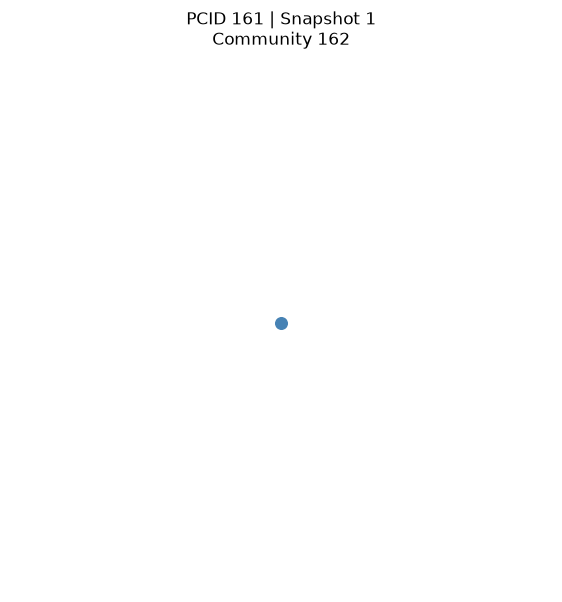

In [67]:
import networkx as nx
import matplotlib.pyplot as plt

FIGURES = RESULTS / "network_evolution"
FIGURES.mkdir(exist_ok=True)

for step in community_timeline:

    timestep = step["timestep"]
    community = step["community"]
    G = step["graph"]

    # Nodes belonging to this community
    community_nodes = [
        n
        for n, data in G.nodes(data=True)
        if data.get("community") == community
    ]

    subgraph = G.subgraph(community_nodes)

    plt.figure(figsize=(7,7))

    pos = nx.spring_layout(
        subgraph,
        seed=42
    )

    colors = []

    for _, data in subgraph.nodes(data=True):

        label = data.get("label", 0)

        if label == 1:
            colors.append("red")          # illicit
        elif label == 2:
            colors.append("orange")       # unknown
        else:
            colors.append("steelblue")    # licit

    nx.draw_networkx_nodes(
        subgraph,
        pos,
        node_size=70,
        node_color=colors,
    )

    nx.draw_networkx_edges(
        subgraph,
        pos,
        alpha=0.4,
        width=0.8,
    )

    plt.title(
        f"PCID {top_pcid} | Snapshot {timestep}\nCommunity {community}"
    )

    plt.axis("off")

    plt.savefig(
        FIGURES / f"pcid_{top_pcid}_snapshot_{timestep}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [68]:
summary_rows = []

for step in community_timeline:

    G = step["graph"]

    nodes = [
        n
        for n, d in G.nodes(data=True)
        if d["community"] == step["community"]
    ]

    fraud = sum(
        G.nodes[n].get("label",0)==1
        for n in nodes
    )

    summary_rows.append({

        "Snapshot": step["timestep"],
        "Community": step["community"],
        "Nodes": len(nodes),
        "Fraud Nodes": fraud,
        "Fraud Ratio": fraud/len(nodes) if nodes else 0,
        "Match Score": step["score"]

    })

case_summary = pd.DataFrame(summary_rows)

case_summary

,Snapshot,Community,Nodes,Fraud Nodes,Fraud Ratio,Match Score
0,1,162,1,0,0.0,1.0


In [69]:
analysis_df["pcid"].value_counts().head(20)

pcid
55     4
56     4
74     4
84     4
85     4
93     4
121    4
137    4
161    4
180    4
191    4
212    4
214    4
234    4
257    4
261    4
283    4
303    4
314    4
321    4
Name: count, dtype: int64

In [70]:
pcid_stats = (
    analysis_df.groupby("pcid")
    .agg(
        snapshots=("timestep", "count"),
        max_afei=("afei", "max"),
        mean_afei=("afei", "mean"),
    )
)

pcid_stats = pcid_stats.sort_values(
    ["snapshots", "max_afei"],
    ascending=[False, False]
)

pcid_stats.head(10)

,snapshots,max_afei,mean_afei
pcid,,,
161,4,0.535940,0.368954
212,4,0.398229,0.325889
137,4,0.340807,0.311595
121,4,0.329233,0.295157
55,4,0.316804,0.270487
56,4,0.315456,0.301716
257,4,0.309976,0.303505
180,4,0.307132,0.288773
214,4,0.306339,0.281285


In [71]:
analysis_df["pcid"].value_counts().head(20)

pcid
55     4
56     4
74     4
84     4
85     4
93     4
121    4
137    4
161    4
180    4
191    4
212    4
214    4
234    4
257    4
261    4
283    4
303    4
314    4
321    4
Name: count, dtype: int64

In [72]:
pcid_stats = (
    analysis_df.groupby("pcid")
    .agg(
        snapshots=("timestep", "count"),
        max_afei=("afei", "max"),
        mean_afei=("afei", "mean")
    )
)

pcid_stats = pcid_stats.query("snapshots >= 4")
pcid_stats = pcid_stats.sort_values("max_afei", ascending=False)

pcid_stats.head(10)

,snapshots,max_afei,mean_afei
pcid,,,
161,4,0.535940,0.368954
212,4,0.398229,0.325889
137,4,0.340807,0.311595
121,4,0.329233,0.295157
55,4,0.316804,0.270487
56,4,0.315456,0.301716
257,4,0.309976,0.303505
180,4,0.307132,0.288773
214,4,0.306339,0.281285


In [84]:
top_pcid = 701
community_timeline = timeline.timelines[top_pcid]

In [85]:
for step in community_timeline:
    print(
        step["timestep"],
        step["community"],
        step["score"]
    )

3 148 1.0
4 16 0.7077
5 95 0.7281
6 9 0.7476


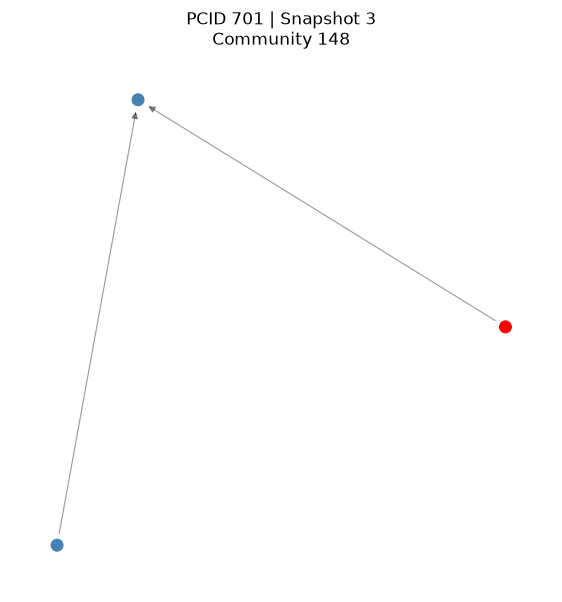

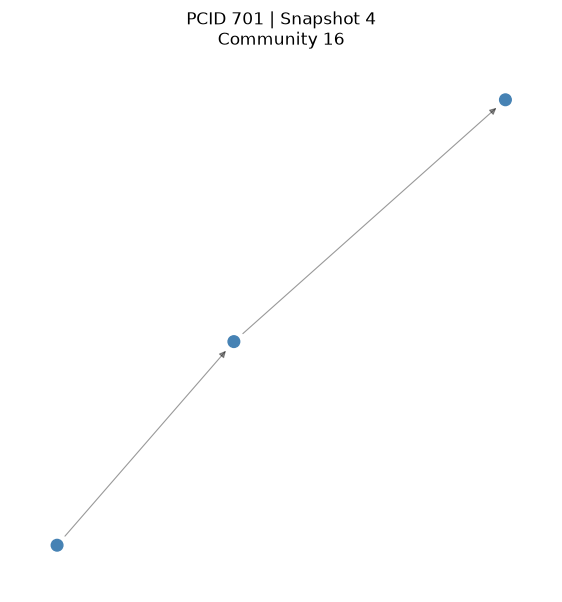

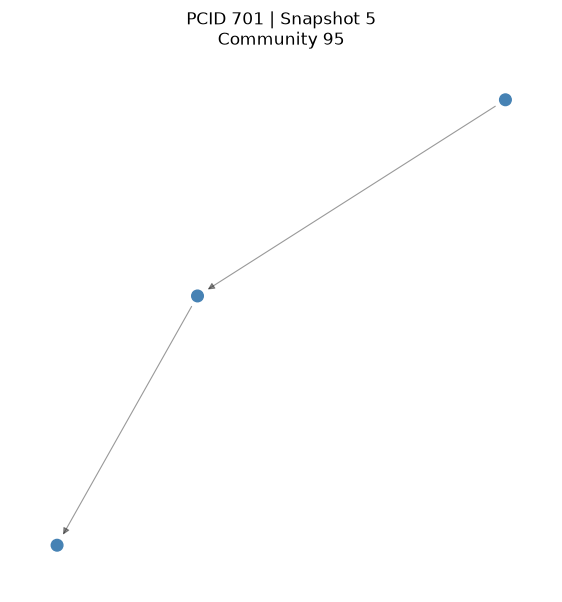

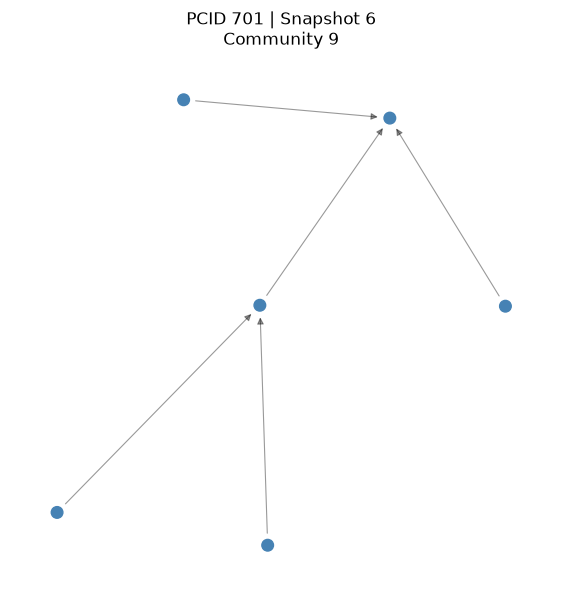

In [86]:
import networkx as nx
import matplotlib.pyplot as plt

FIGURES = RESULTS / "network_evolution"
FIGURES.mkdir(exist_ok=True)

for step in community_timeline:

    timestep = step["timestep"]
    community = step["community"]
    G = step["graph"]

    # Nodes belonging to this community
    community_nodes = [
        n
        for n, data in G.nodes(data=True)
        if data.get("community") == community
    ]

    subgraph = G.subgraph(community_nodes)

    plt.figure(figsize=(7,7))

    pos = nx.spring_layout(
        subgraph,
        seed=42
    )

    colors = []

    for _, data in subgraph.nodes(data=True):

        label = data.get("label", 0)

        if label == 1:
            colors.append("red")          # illicit
        elif label == 2:
            colors.append("orange")       # unknown
        else:
            colors.append("steelblue")    # licit

    nx.draw_networkx_nodes(
        subgraph,
        pos,
        node_size=70,
        node_color=colors,
    )

    nx.draw_networkx_edges(
        subgraph,
        pos,
        alpha=0.4,
        width=0.8,
    )

    plt.title(
        f"PCID {top_pcid} | Snapshot {timestep}\nCommunity {community}"
    )

    plt.axis("off")

    plt.savefig(
        FIGURES / f"pcid_{top_pcid}_snapshot_{timestep}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [87]:
plt.savefig(
    FIGURES / f"pcid_{top_pcid}_snapshot_{timestep}.png",
    dpi=300,
    bbox_inches="tight",
)

<Figure size 640x480 with 0 Axes>

In [88]:
case_summary.to_csv(
    RESULTS / "highest_risk_case_study.csv",
    index=False
)

In [89]:
import json

case_metadata = {
    "selected_pcid": int(top_pcid),
    "num_snapshots": len(community_timeline),
    "max_afei": float(
        analysis_df.loc[
            analysis_df["pcid"] == top_pcid,
            "afei"
        ].max()
    )
}

with open(RESULTS / "case_study_metadata.json", "w") as f:
    json.dump(case_metadata, f, indent=4)

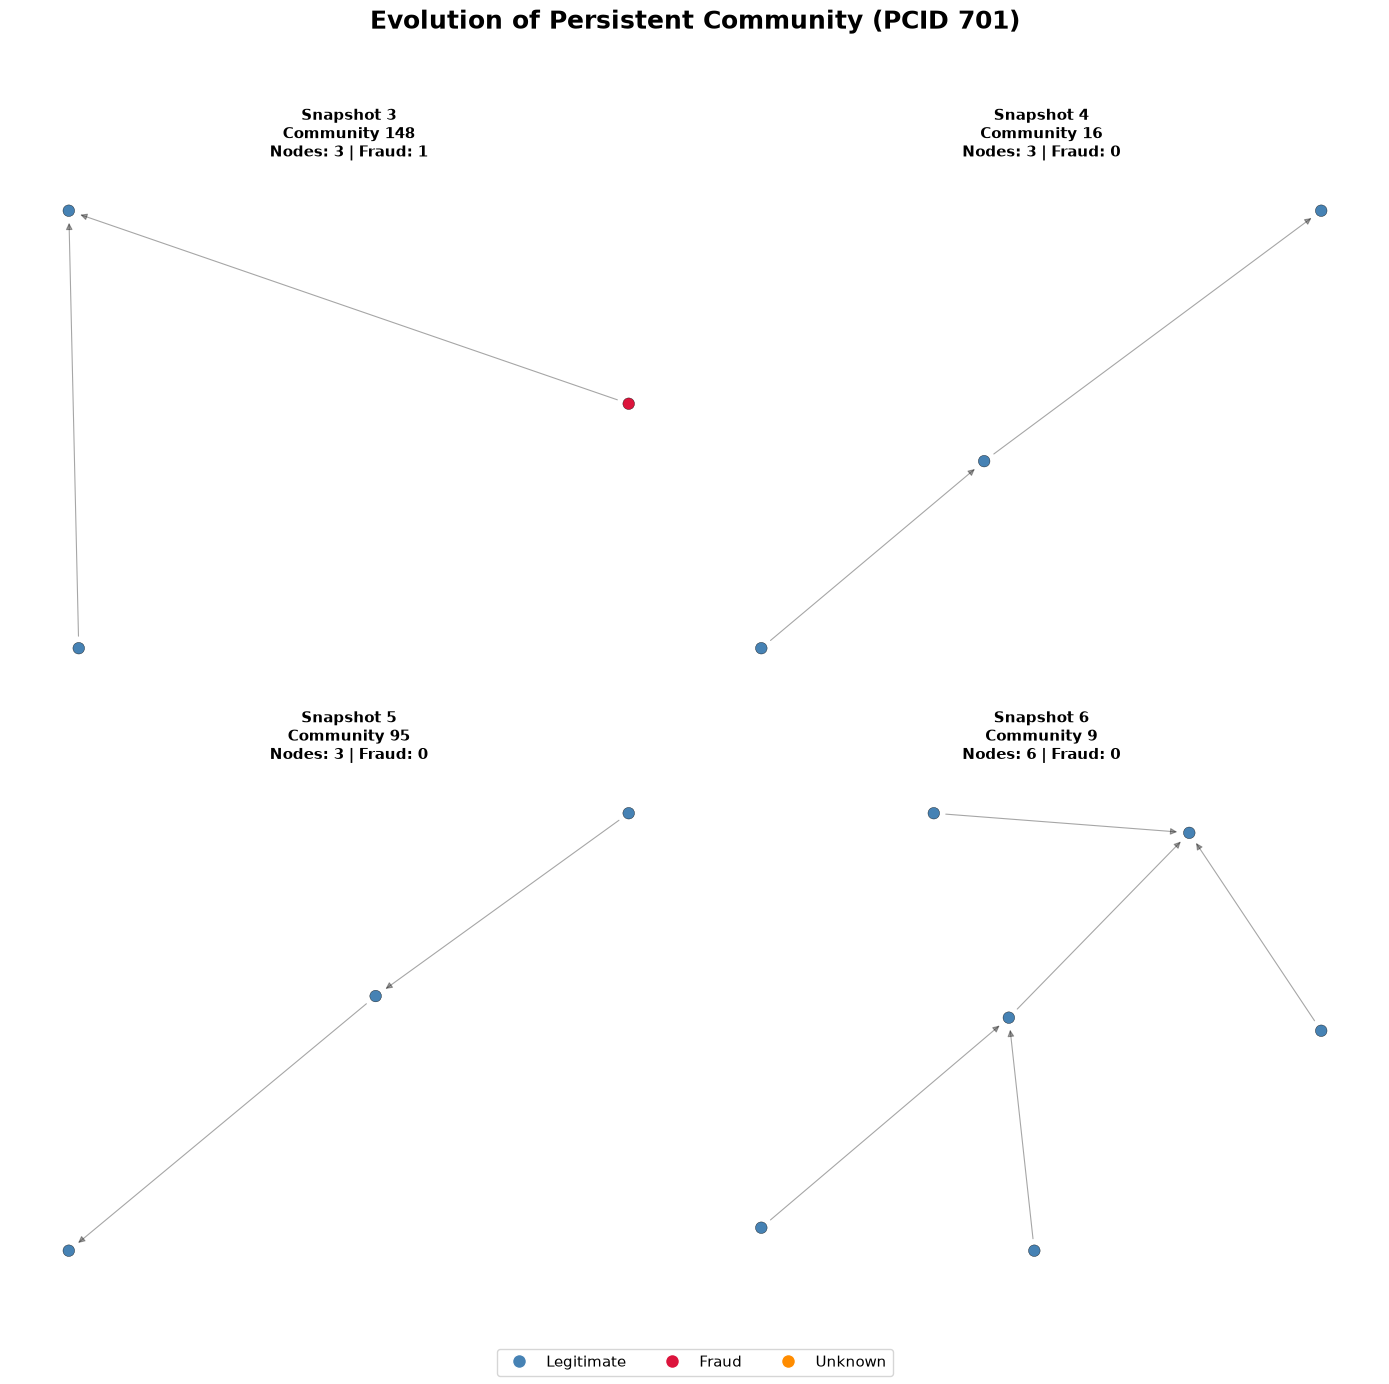

In [90]:
import math
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Create a single figure showing community evolution
# ---------------------------------------------------------

n = len(community_timeline)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(7 * cols, 7 * rows)
)

axes = axes.flatten()

for ax, step in zip(axes, community_timeline):

    timestep = step["timestep"]
    community = step["community"]
    G = step["graph"]

    # Nodes belonging to this community
    community_nodes = [
        node
        for node, data in G.nodes(data=True)
        if data.get("community") == community
    ]

    subgraph = G.subgraph(community_nodes)

    # Keep layout deterministic
    pos = nx.spring_layout(
        subgraph,
        seed=42,
        k=0.5
    )

    node_colors = []

    for node, data in subgraph.nodes(data=True):

        label = data.get("label", 0)

        if label == 1:
            node_colors.append("crimson")       # Fraud
        elif label == 2:
            node_colors.append("darkorange")    # Unknown
        else:
            node_colors.append("steelblue")     # Legitimate

    nx.draw_networkx_edges(
        subgraph,
        pos,
        ax=ax,
        alpha=0.35,
        width=0.8
    )

    nx.draw_networkx_nodes(
        subgraph,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=70,
        edgecolors="black",
        linewidths=0.25
    )

    fraud_nodes = sum(
        data.get("label", 0) == 1
        for _, data in subgraph.nodes(data=True)
    )

    ax.set_title(
        f"Snapshot {timestep}\n"
        f"Community {community}\n"
        f"Nodes: {subgraph.number_of_nodes()} | Fraud: {fraud_nodes}",
        fontsize=11,
        weight="bold"
    )

    ax.axis("off")

# Hide unused subplot (if any)
for ax in axes[len(community_timeline):]:
    ax.axis("off")

# Main title
fig.suptitle(
    f"Evolution of Persistent Community (PCID {top_pcid})",
    fontsize=18,
    weight="bold"
)

# Legend
from matplotlib.lines import Line2D

legend = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='steelblue', markersize=10,
           label='Legitimate'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='crimson', markersize=10,
           label='Fraud'),
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor='darkorange', markersize=10,
           label='Unknown')
]

fig.legend(
    handles=legend,
    loc="lower center",
    ncol=3,
    fontsize=11
)

plt.tight_layout(rect=[0,0.05,1,0.95])

# Save
fig.savefig(
    RESULTS / f"pcid_{top_pcid}_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
from collections import Counter
import pandas as pd

candidate_pcids = []

for pcid, history in timeline.timelines.items():

    # Only consider persistent communities
    if len(history) < 4:
        continue

    all_labels = []

    for step in history:
        G = step["graph"]
        community = step["community"]

        nodes = [
            n for n, d in G.nodes(data=True)
            if d["community"] == community
        ]

        all_labels.extend(
            G.nodes[n]["label"]
            for n in nodes
        )

    labels = set(all_labels)

    candidate_pcids.append({
        "pcid": pcid,
        "snapshots": len(history),
        "labels": labels,
        "num_classes": len(labels),
        "max_afei": analysis_df.loc[
            analysis_df["pcid"] == pcid,
            "afei"
        ].max()
    })

candidate_df = pd.DataFrame(candidate_pcids)

candidate_df = (
    candidate_df
    .sort_values(
        ["num_classes", "max_afei"],
        ascending=[False, False]
    )
)

candidate_df.head(20)

,pcid,snapshots,labels,num_classes,max_afei
53,701,4,"{0, 1}",2,0.293523
9,206,5,"{0, 1}",2,0.268645
52,693,6,"{0, 1}",2,NaN
81,1084,6,"{0, 1}",2,NaN
88,1132,5,"{0, 1}",2,NaN
101,1448,4,"{0, 1}",2,NaN
125,1928,4,"{0, 1}",2,NaN
126,1939,4,"{0, 1}",2,NaN
127,1955,4,"{0, 1}",2,NaN
130,1989,4,"{0, 1}",2,NaN
